# Install and Import Dependencies


In [1]:
!pip install insightface

# Current transformers 4.40 does not have text_model inside CLIPTextModel
# The repo has a dependencies files Arc2Face/requirements.txt.
# Couldn't install from the rqmnts text. Some subprocess fails or whatever
# Manually installed transformers==4.36.0.
# Added diffusers to the mix. Current version is incompatible. Installed diffusers==0.29.2
# Current peft installation is incompatible. Version number is not mentined in the rqmnts.
# Tried installing 0.7.1, 0.8.2, 0.9.0, 0.10.0
# !pip install -r /content/Arc2Face/requirements.txt
!pip install transformers==4.36.0 diffusers==0.29.2 gradio==5.7.1 sentence-transformers==2.2.2

# retrying peft installation by uninstalling it then re-installing it at 0.10.0
# retried again at 0.11.0
# Another issue was probably "stale runtime". I started a new session and my problem was solved. Hahaha...
!pip uninstall -y peft
!rm -rf /usr/local/lib/python3.13/dist-packages/peft
!rm -rf /usr/local/lib/python3.13/dist-packages/peft-*.dist-info
!pip install peft==0.11.0

# I could not find arc2face package in PyPl.
# Trying to downlaod from other sources. Checking the paper for "arc2face" source repo

!git clone https://github.com/foivospar/Arc2Face.git /content/Arc2Face


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 83.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 77.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.8/126.8 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.0/86.0 kB 9.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 MB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.1/320.1 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 123.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.

In [2]:
!pip show transformers diffusers peft huggingface_hub

Name: transformers
Version: 4.36.0
Summary: State-of-the-art Machine Learning for JAX, PyTorch and TensorFlow
Home-page: https://github.com/huggingface/transformers
Author: The Hugging Face team (past and future) with the help of all our contributors (https://github.com/huggingface/transformers/graphs/contributors)
Author-email: transformers@huggingface.co
License: Apache 2.0 License
Location: /usr/local/lib/python3.13/dist-packages
Requires: filelock, huggingface-hub, numpy, packaging, pyyaml, regex, requests, safetensors, tokenizers, tqdm
Required-by: peft, sentence-transformers
---
Name: diffusers
Version: 0.29.2
Summary: State-of-the-art diffusion in PyTorch and JAX.
Home-page: https://github.com/huggingface/diffusers
Author: The Hugging Face team (past and future) with the help of all our contributors (https://github.com/huggingface/diffusers/graphs/contributors)
Author-email: diffusers@huggingface.co
License: Apache 2.0 License
Location: /usr/local/lib/python3.13/dist-packages
Re

In [3]:
import torch
import os
import sys
import glob
import zipfile
import pathlib
from insightface.app import FaceAnalysis
from PIL import Image
from pathlib import Path
import numpy as np

In [4]:
# Define providers dynamically based on CUDA availability
providers = ['CPUExecutionProvider']
if torch.cuda.is_available():
    providers = ['CUDAExecutionProvider', 'CPUExecutionProvider']
model_root = './' # ----
zip_path = f"{model_root}models/antelopev2.zip" # ----
extract_folder = f"{model_root}models/" # ----

try:                                                                        # ----
    FaceAnalysis(name='antelopev2', root=model_root, providers=providers)   # ----
    # FaceAnalysis(name='buffalo_l', root=model_root, providers=providers)    # ----
except AssertionError:                                                      # ----
    print("Error during zip extraction. Rectification in following steps")  # ----
    !rm -rf /content/models/antelopev2
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_folder) # ----
    print(f"Extracted {zip_path} to {extract_folder}/") # ----


download_path: ./models/antelopev2


100%|██████████| 352210/352210 [00:05<00:00, 67727.91KB/s]


Error during zip extraction. Rectification in following steps
Extracted ./models/antelopev2.zip to ./models//


In [5]:
# This snippet downloads the pretrained weights for Arc2Face Application. Found this on hugging face.
from huggingface_hub import hf_hub_download

hf_hub_download(repo_id="FoivosPar/Arc2Face", filename="arc2face/config.json", local_dir="./models")
hf_hub_download(repo_id="FoivosPar/Arc2Face", filename="arc2face/diffusion_pytorch_model.safetensors", local_dir="./models")
hf_hub_download(repo_id="FoivosPar/Arc2Face", filename="encoder/config.json", local_dir="./models")
hf_hub_download(repo_id="FoivosPar/Arc2Face", filename="encoder/pytorch_model.bin", local_dir="./models")

hf_hub_download(repo_id="FoivosPar/Arc2Face", filename="arcface.onnx", local_dir="./models/antelopev2")
!rm -rf /content/models/antelopev2/glintr100.onnx

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

arc2face/diffusion_pytorch_model.safeten(…):   0%|          | 0.00/3.44G [00:00<?, ?B/s]

config.json:   0%|          | 0.00/560 [00:00<?, ?B/s]

encoder/pytorch_model.bin:   0%|          | 0.00/492M [00:00<?, ?B/s]

arcface.onnx:   0%|          | 0.00/261M [00:00<?, ?B/s]

In [7]:
sys.path.append('./Arc2Face')

# Template Generation


3
<class 'list'>
0 /content/mrpedo.jpg


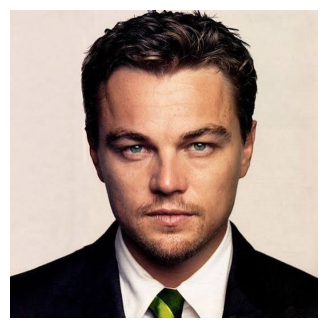

1 /content/mrpedo_2.jpg


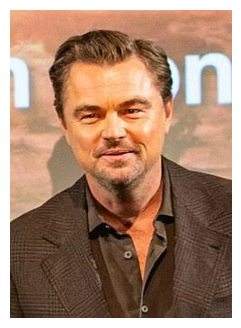

2 /content/tahmeed.jpg


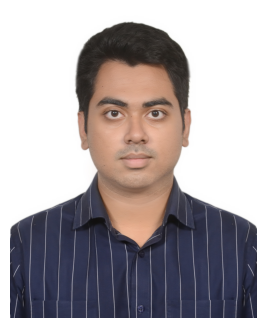

In [17]:
# Updated the root argument
#### IT UNZIPPED ANYWAY ####
# It won't unzip if the damn thing already exists.
app = FaceAnalysis(name='antelopev2', root=model_root, providers=providers)
# app = FaceAnalysis(name='buffalo_l', root=model_root, providers=providers)
app.prepare(ctx_id=0, det_size=(640, 640))

# Updated the root argument
app2 = FaceAnalysis(name='antelopev2', root=model_root, providers=providers)
# app2 = FaceAnalysis(name='buffalo_l', root=model_root, providers=providers)
app2.prepare(ctx_id=0, det_size=(480,480))
## Arguments

# image_path = str(sys.argv[1]) # folder path to images
# output_path = str(sys.argv[2]) # folder path to save outputs
# startind = int(sys.argv[3]) # starting index of files to process
# dataset_name = str(sys.argv[4]) # dataset_name = ['lfw', 'cfpfp']
# image_path = '/content/1744362020887.jpg'
image_path = '/content'
output_path = '/content/output'
startind = 0
dataset_name = 'lfw'

# get image and its embedding
if dataset_name == 'lfw': # There was a mistake in this line, lmao.
    targetfiles = sorted(glob.glob(f'{image_path}/*.jpg')) # /path-to-lfw-data-folder/00001.jpg
else:
    targetfiles = sorted(glob.glob(f'{image_path}/**/*/*.jpg'))  # /path-to-cfp-dataset/Data/Images/001/frontal/01.jpg
print(len(targetfiles))
print(type(targetfiles))
# save face templates

save_path_npy = f"{output_path}/InsightFaceTemplates"
os.makedirs(save_path_npy, exist_ok=True)


for imgid, img in enumerate(targetfiles[startind:], start=startind):
    fname1= pathlib.PurePath(str(img))
    print(imgid, fname1)
    imgid_target = Path(str(fname1)).stem
    if dataset_name == 'lfw':
        try:
            img_target = np.array(Image.open(str(fname1)))[:,:,::-1]
            show(img_target)
            try:
                faces_target = app.get(img_target)
                faces_target = sorted(faces_target, key=lambda x:(x['bbox'][2]-x['bbox'][0])*(x['bbox'][3]-x['bbox'][1]))[-1]  # select largest face (if more than one detected)
            except:
                faces_target = app2.get(img_target)
                faces_target = sorted(faces_target, key=lambda x:(x['bbox'][2]-x['bbox'][0])*(x['bbox'][3]-x['bbox'][1]))[-1]  # select largest face (if more than one detected)

            id_emb_target = torch.tensor(faces_target['embedding'], dtype=torch.float16)[None]
            # save outputs
            id_emb_nparr = id_emb_target.detach().cpu().numpy()
            np.save(f'{save_path_npy}/{imgid_target}.npy', id_emb_nparr)
        except:
            continue
    else:
        pathnm1 = str(fname1).split('/') # /path to cfp-dataset/Data/Images/001/frontal/01.jpg
        subid_target = pathnm1[12] # change the index in square bracketes depending on where your cfpfp images are saved. Example subid_target='001'
        laterality = pathnm1[13] # change the index in square bracketes depending on where your cfpfp images are saved. Example laterality='frontal'

        if laterality=='frontal':
            try:
                img_target = np.array(Image.open(str(fname1)))[:,:,::-1]
                show(img_target)
                try:
                    faces_target = app.get(img_target)
                    faces_target = sorted(faces_target, key=lambda x:(x['bbox'][2]-x['bbox'][0])*(x['bbox'][3]-x['bbox'][1]))[-1]  # select largest face (if more than one detected)
                except:
                    faces_target = app2.get(img_target)
                    faces_target = sorted(faces_target, key=lambda x:(x['bbox'][2]-x['bbox'][0])*(x['bbox'][3]-x['bbox'][1]))[-1]  # select largest face (if more than one detected)

                id_emb_target = torch.tensor(faces_target['embedding'], dtype=torch.float16)[None]
                # save outputs
                id_emb_nparr = id_emb_target.detach().cpu().numpy()
                np.save(f'{save_path_npy}/SubID_{subid_target}_ImgID_{imgid_target}_{laterality}.npy', id_emb_nparr)

            except:
                continue

In [ ]:

# ## Extract templates using ArcFace finetuned with Orthogonal Projection Loss. Follow the InsightFace repo instructions and put model.pt in models_zoo

# # import argparse

# import cv2
# import numpy as np
# import torch

# from backbones import get_model


# @torch.no_grad()
# def inference(weight, name, img):
#     if img is None:
#         img = np.random.randint(0, 255, size=(112, 112, 3), dtype=np.uint8)
#     else:
#         img = cv2.imread(img)
#         img = cv2.resize(img, (112, 112))

#     img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#     img = np.transpose(img, (2, 0, 1))
#     img = torch.from_numpy(img).unsqueeze(0).float()
#     img.div_(255).sub_(0.5).div_(0.5)
#     net = get_model(name, fp16=False)
#     net.load_state_dict(torch.load(weight, map_location=torch.device('cpu')))
#     net.eval()
#     feat = net(img).numpy()
#     # save the feat
#     np.save('img_name.npy',feat)


# inference(args.weight, args.network, args.img)

# Template 2 Face

In [11]:
# Found the source repo. Cloned it into the environment.
# Linked their asses to the notebook.
from arc2face.models import CLIPTextModelWrapper
from arc2face.utils import project_face_embs

/usr/local/lib/python3.13/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.13/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.13/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def show(img, title=None, bgr=None, figsize=(4, 4)):
    """Display a PIL Image or numpy array inline."""
    if isinstance(img, Image.Image):
        arr = np.array(img)
    else:
        arr = np.asarray(img)

    # cv2 loads BGR; auto-detect if not told
    if bgr is None:
        bgr = not isinstance(img, Image.Image) and arr.ndim == 3 and arr.shape[2] == 3
    if bgr and arr.ndim == 3 and arr.shape[2] == 3:
        arr = arr[:, :, ::-1]

    # normalize float arrays outside [0, 1]
    if np.issubdtype(arr.dtype, np.floating):
        lo, hi = float(arr.min()), float(arr.max())
        if lo < 0 or hi > 1:
            arr = (arr - lo) / (hi - lo + 1e-8)

    plt.figure(figsize=figsize)
    plt.imshow(arr.squeeze(), cmap="gray" if arr.squeeze().ndim == 2 else None)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

In [12]:
from diffusers import (
    StableDiffusionPipeline,
    UNet2DConditionModel,
    DPMSolverMultistepScheduler,
)

# from arc2face import CLIPTextModelWrapper, project_face_embs

import torch
import os
import sys
import glob
import pathlib
from pathlib import Path
import random
from insightface.app import FaceAnalysis
from PIL import Image
import numpy as np

base_model = 'runwayml/stable-diffusion-v1-5'

## Arc2Face
encoder = CLIPTextModelWrapper.from_pretrained(
    'models', subfolder="encoder", torch_dtype=torch.float16
)

unet = UNet2DConditionModel.from_pretrained(
    'models', subfolder="arc2face", torch_dtype=torch.float16
)

pipeline = StableDiffusionPipeline.from_pretrained(
        base_model,
        text_encoder=encoder,
        unet=unet,
        torch_dtype=torch.float16,
        safety_checker=None
    )

app = FaceAnalysis(name='antelopev2', root='./', providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
app.prepare(ctx_id=0, det_size=(480, 480))

app2 = FaceAnalysis(name='antelopev2', root='./', providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
app2.prepare(ctx_id=0, det_size=(640,640))

cos = torch.nn.CosineSimilarity(dim=1, eps=1e-6)
##########
pipeline.scheduler = DPMSolverMultistepScheduler.from_config(pipeline.scheduler.config)
pipeline = pipeline.to('cuda')


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .
/usr/local/lib/python3.13/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:197: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


In [18]:

templatepath =  '/content/output/InsightFaceTemplates'
templates = sorted(glob.glob(f'{templatepath}/*.npy'))
print(len(templates))


3


In [14]:
## positive disruptor generation
def add_noise(embedding, std=0.2):
    #noise = (var**0.5)*torch.randn(embedding.shape, dtype=torch.float16).cuda()
    #return embedding + noise
    return embedding + torch.randn_like(embedding) * std

def feature_dropout(embedding, p=0.8):
    mask = torch.bernoulli(torch.ones_like(embedding) * p)
    return embedding * mask


## negative feature/orthogonal disruptor generation
def gram_schmidt(v):
    """
    Finds an orthogonal vector to the given vector using the Gram-Schmidt process.
    """

    u = torch.randn_like(v)  # Generate a random vector of the same size
    u = u - (torch.dot(u, v) / torch.dot(v, v)) * v
    #return u / torch.norm(u)
    return u

def synth_neg(folder_path):
   # List all files in the folder
    files = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]

    # Choose a random file
    random_file = random.choice(files)

    # Construct the full path to the file
    file_path = os.path.join(folder_path, random_file)
    synth = torch.from_numpy(np.load(f"{file_path}", allow_pickle=True))
    synth = synth.to(torch.float16).cuda()
    return synth


In [19]:
print(len(templates))

3


0


  0%|          | 0/25 [00:00<?, ?it/s]

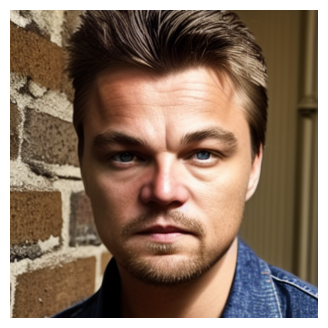

cosine noisy: tensor([0.9751], device='cuda:0', dtype=torch.float16)


  0%|          | 0/25 [00:00<?, ?it/s]

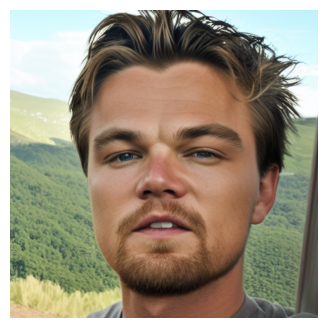

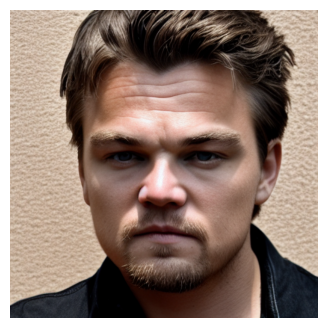

  0%|          | 0/25 [00:00<?, ?it/s]

cosine mask: tensor([0.9238], device='cuda:0', dtype=torch.float16)


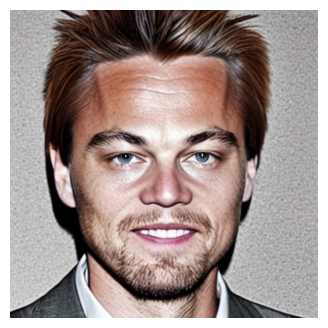

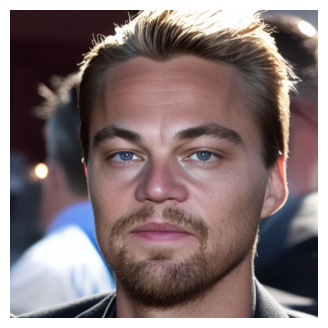

  0%|          | 0/25 [00:00<?, ?it/s]

cosine ortho: tensor([2.9802e-07], device='cuda:0', dtype=torch.float16)


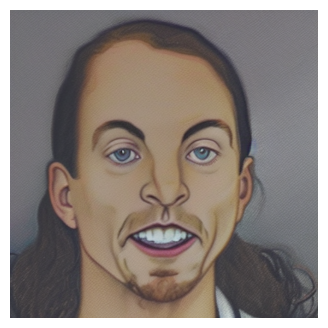

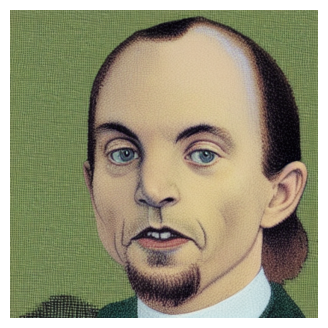

  0%|          | 0/25 [00:00<?, ?it/s]

cosine synth: tensor([0.0676], device='cuda:0', dtype=torch.float16)


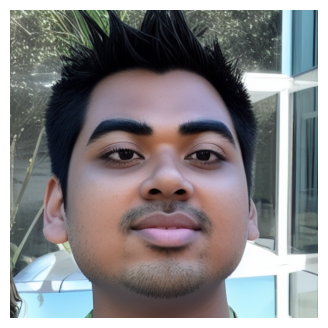

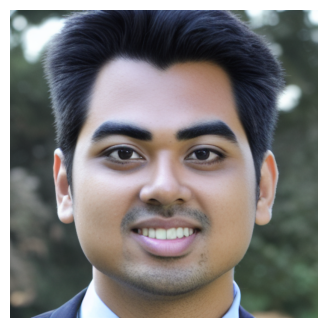

1


  0%|          | 0/25 [00:00<?, ?it/s]

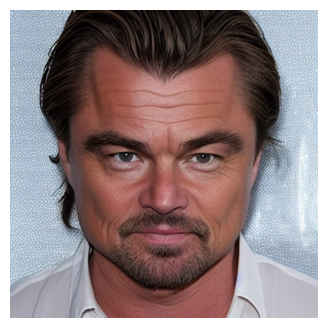

cosine noisy: tensor([0.9746], device='cuda:0', dtype=torch.float16)


  0%|          | 0/25 [00:00<?, ?it/s]

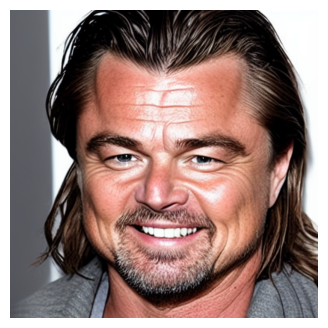

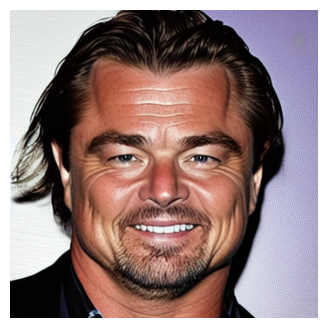

  0%|          | 0/25 [00:00<?, ?it/s]

cosine mask: tensor([0.9087], device='cuda:0', dtype=torch.float16)


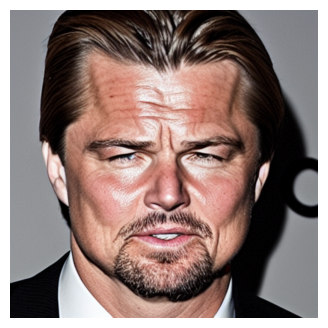

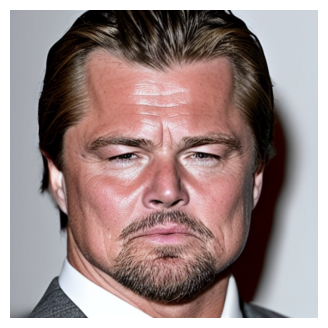

  0%|          | 0/25 [00:00<?, ?it/s]

cosine ortho: tensor([1.4722e-05], device='cuda:0', dtype=torch.float16)


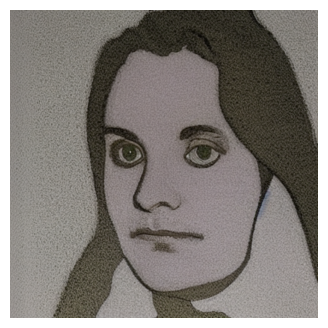

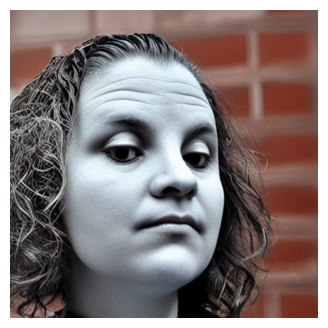

  0%|          | 0/25 [00:00<?, ?it/s]

cosine synth: tensor([0.6099], device='cuda:0', dtype=torch.float16)


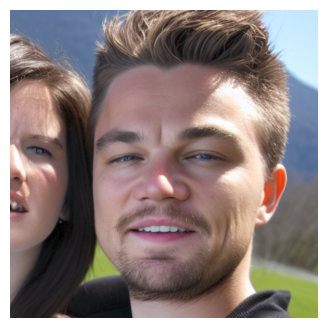

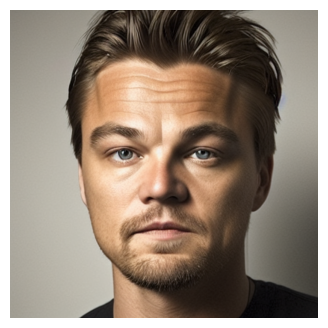

2


  0%|          | 0/25 [00:00<?, ?it/s]

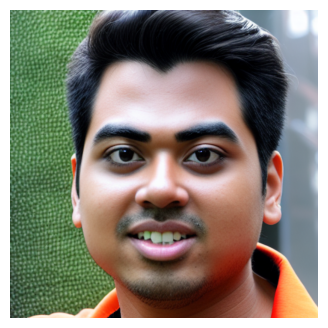

cosine noisy: tensor([0.9697], device='cuda:0', dtype=torch.float16)


  0%|          | 0/25 [00:00<?, ?it/s]

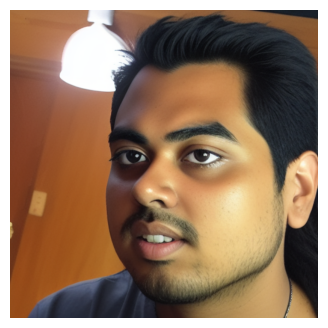

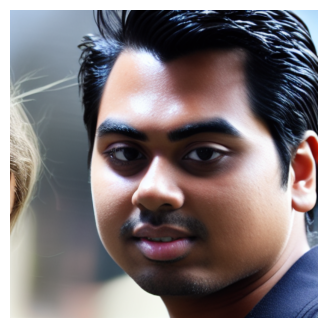

  0%|          | 0/25 [00:00<?, ?it/s]

cosine mask: tensor([0.8115], device='cuda:0', dtype=torch.float16)


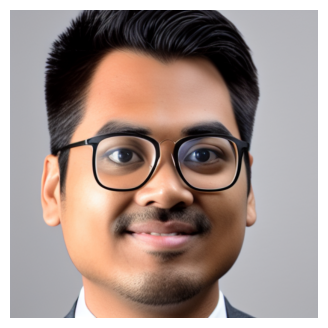

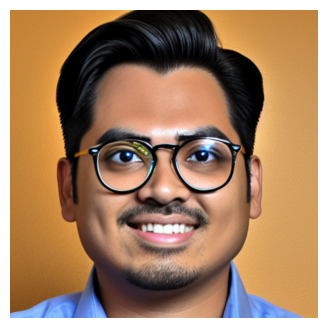

  0%|          | 0/25 [00:00<?, ?it/s]

cosine ortho: tensor([3.0518e-05], device='cuda:0', dtype=torch.float16)


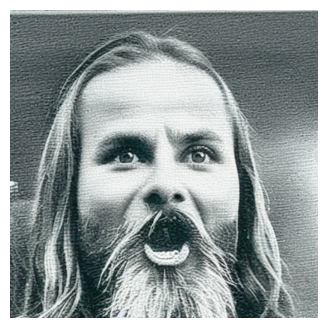

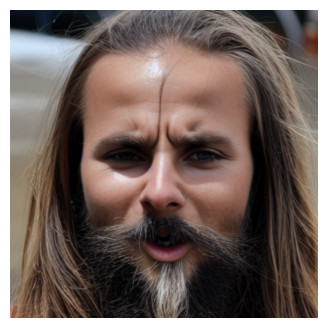

  0%|          | 0/25 [00:00<?, ?it/s]

cosine synth: tensor([0.0676], device='cuda:0', dtype=torch.float16)


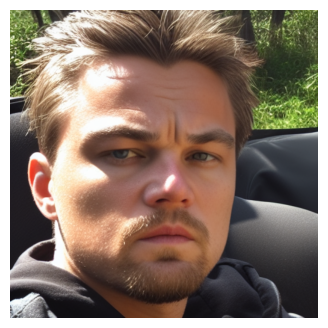

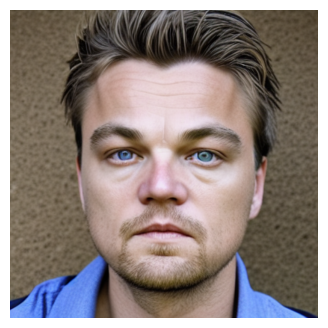

In [20]:

folder_path = '/content/output/InsightFaceTemplates'
# save outputs
# save_path = f"/path-to-save-generatedimages"
# os.makedirs(save_path, exist_ok=True)
num_images = 2 # here, 2 images are shown for example, you can select 4/6...
for ind, tempfile in enumerate(templates):
    print(ind)
    id_emb_target = torch.from_numpy(np.load(f"{tempfile}", allow_pickle=True)).cuda()
    fname= pathlib.PurePath(str(tempfile))
    filename = Path(str(fname)).stem

    ## reconstruct original template
    template = id_emb_target.to(torch.float16)
    template = id_emb_target/torch.norm(id_emb_target, dim=1, keepdim=True)   # normalize embedding
    id_emb_template = project_face_embs(pipeline, template)    # pass through the encoder
    image = pipeline(prompt_embeds=id_emb_template, num_inference_steps=25, guidance_scale=3.0, num_images_per_prompt=1).images
    # image[0].save(f"{save_path}/{filename}_template_InsightFace.png")
    show(image[0])

    ## reconstruct positive disruptors

    # noise
    id_emb_noisy = add_noise(id_emb_target)# add noise to id_emb_target not template
    id_emb_noisy = id_emb_noisy/torch.norm(id_emb_noisy, dim=1, keepdim=True)   # normalize noisy embedding
    id_emb_noisy_project = project_face_embs(pipeline, id_emb_noisy)
    print('cosine noisy:',cos(template, id_emb_noisy))
    images_noisy = pipeline(prompt_embeds=id_emb_noisy_project, num_inference_steps=25, guidance_scale=3.0, num_images_per_prompt=num_images).images
    for id, img in enumerate(images_noisy):

        # img.save(f"{save_path}/{filename}_{id}_customnoise_InsightFace.png")
        show(img)
    # mask
    pos_mask = feature_dropout(id_emb_target)
    pos_mask = pos_mask/torch.norm(pos_mask, dim=1, keepdim=True)
    id_emb_mask_template = project_face_embs(pipeline, pos_mask)    # pass through the encoder
    images_mask = pipeline(prompt_embeds=id_emb_mask_template, num_inference_steps=25, guidance_scale=3.0, num_images_per_prompt=num_images).images
    print('cosine mask:',cos(template, pos_mask))
    for id, img in enumerate(images_mask):

        # img.save(f"{save_path}/{filename}_{id}_custommask_InsightFace.png")
        show(img)

    ## reconstruct negative disruptors
    # orthognal
    neg_ortho = gram_schmidt(torch.squeeze(id_emb_target,0))
    neg_ortho = torch.unsqueeze(neg_ortho,0)
    neg_ortho = neg_ortho/torch.norm(neg_ortho, dim=1, keepdim=True)
    id_emb_ortho_template = project_face_embs(pipeline, neg_ortho)    # pass through the encoder
    images_ortho = pipeline(prompt_embeds=id_emb_ortho_template, num_inference_steps=25, guidance_scale=3.0, num_images_per_prompt=num_images).images
    print('cosine ortho:',cos(template, neg_ortho))
    for id, img in enumerate(images_ortho):

        # img.save(f"{save_path}/{filename}_{id}_customortho_InsightFace.png")
        show(img)

    # synthetic
    neg_synth = synth_neg(folder_path)
    neg_synth = neg_synth/torch.norm(neg_synth, dim=1, keepdim=True)
    id_emb_synth_template = project_face_embs(pipeline, neg_synth)    # pass through the encoder
    images_synth = pipeline(prompt_embeds=id_emb_synth_template, num_inference_steps=25, guidance_scale=3.0, num_images_per_prompt=num_images).images
    print('cosine synth:',cos(template, neg_synth))
    for id, img in enumerate(images_synth):

        # img.save(f"{save_path}/{filename}_{id}_customsynth_InsightFace.png")
        show(img)







In [ ]:
from transformers import CLIPTextModel
import inspect

# Class-level check — expect False. Not evidence of anything.
print(hasattr(CLIPTextModel, "text_model"))

# What's actually in __init__
print(inspect.getsource(CLIPTextModel.__init__))

# Where the file lives, if you want to read it
print(inspect.getfile(CLIPTextModel))

False
    def __init__(self, config: CLIPTextConfig):
        super().__init__(config)
        self.text_model = CLIPTextTransformer(config)
        # Initialize weights and apply final processing
        self.post_init()

/usr/local/lib/python3.13/dist-packages/transformers/models/clip/modeling_clip.py


In [ ]:
from transformers import CLIPTextModel
m = CLIPTextModel.from_pretrained("openai/clip-vit-base-patch32")
print(hasattr(m, "text_model"))
print([n for n, _ in m.named_children()])

/usr/local/lib/python3.13/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

True
['text_model']


# Directly from Hugging Face

In [ ]:
from diffusers import (
    StableDiffusionPipeline,
    UNet2DConditionModel,
    DPMSolverMultistepScheduler,
)

from arc2face import CLIPTextModelWrapper, project_face_embs

import torch
from insightface.app import FaceAnalysis
from PIL import Image
import numpy as np

# Arc2Face is built upon SD1.5
# The repo below can be used instead of the now deprecated 'runwayml/stable-diffusion-v1-5'
base_model = 'stable-diffusion-v1-5/stable-diffusion-v1-5'

encoder = CLIPTextModelWrapper.from_pretrained(
    'models', subfolder="encoder", torch_dtype=torch.float16
)

unet = UNet2DConditionModel.from_pretrained(
    'models', subfolder="arc2face", torch_dtype=torch.float16
)

pipeline = StableDiffusionPipeline.from_pretrained(
        base_model,
        text_encoder=encoder,
        unet=unet,
        torch_dtype=torch.float16,
        safety_checker=None
    )
pipeline.scheduler = DPMSolverMultistepScheduler.from_config(pipeline.scheduler.config)
pipeline = pipeline.to('cuda')


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


In [21]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def show_bbox(img, bboxes, bgr=False, kps=None, figsize=(5, 5)):
    """Draw insightface bboxes [x1, y1, x2, y2] over an image."""
    arr = np.asarray(img)
    if bgr and arr.ndim == 3 and arr.shape[2] == 3:
        arr = arr[:, :, ::-1]

    bboxes = np.atleast_2d(np.asarray(bboxes, dtype=float))

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(arr)

    for i, (x1, y1, x2, y2) in enumerate(bboxes[:, :4]):
        ax.add_patch(patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor="lime", facecolor="none"))
        ax.text(x1, y1 - 4, str(i), color="lime",
                fontsize=10, weight="bold")

    if kps is not None:
        kps = np.asarray(kps).reshape(-1, 5, 2)
        for k in kps:
            ax.scatter(k[:, 0], k[:, 1], s=18, c="red", marker="x")

    ax.axis("off")
    plt.show()

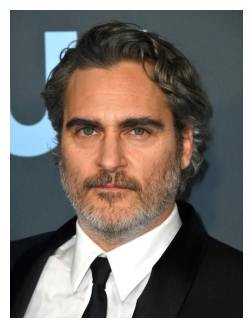

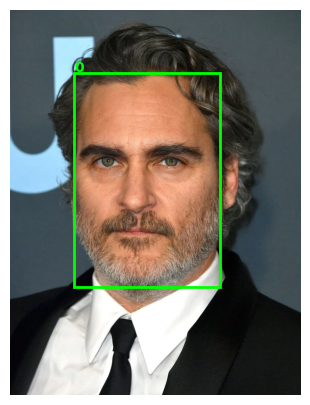

In [22]:
app = FaceAnalysis(name='antelopev2', root='./', providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
app.prepare(ctx_id=0, det_size=(640, 640))

img = np.array(Image.open('/content/joacquin.png'))
show(img, bgr=False)

faces = app.get(img)
faces = sorted(faces, key=lambda x:(x['bbox'][2]-x['bbox'][0])*(x['bbox'][3]-x['bbox'][1]))[-1]  # select largest face (if more than one detected)
id_emb = torch.tensor(faces['embedding'], dtype=torch.float16)[None].cuda()
id_emb = id_emb/torch.norm(id_emb, dim=1, keepdim=True)   # normalize embedding
id_emb = project_face_embs(pipeline, id_emb)    # pass through the encoder

show_bbox(img, faces['bbox'], bgr=False)


In [23]:
num_images = 4
images = pipeline(prompt_embeds=id_emb, num_inference_steps=25, guidance_scale=1.0, num_images_per_prompt=num_images).images

  0%|          | 0/25 [00:00<?, ?it/s]

4


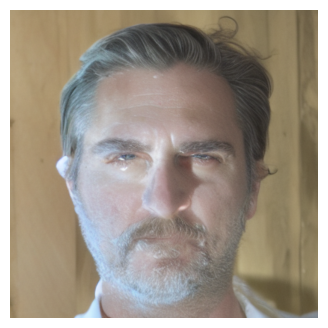

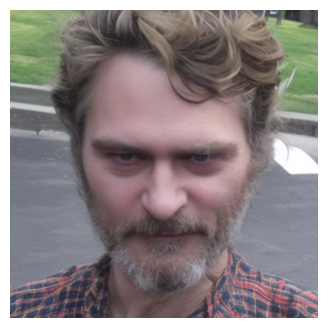

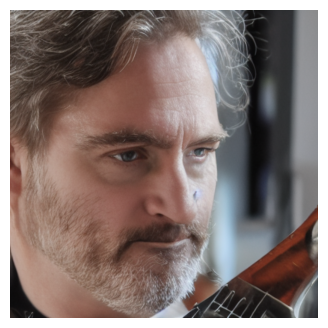

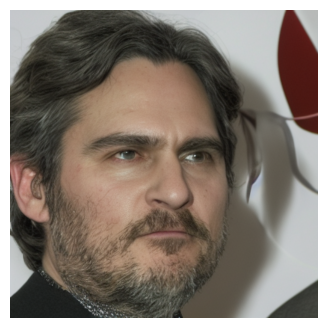

In [24]:
print(len(images))
for image in images:
  show(image)

In [ ]:
print(type(faces))
print(len(faces))
print(faces['bbox'])

<class 'insightface.app.common.Face'>
9
[158.2755   99.44632 416.529   444.95282]
